# Bloque 2

## **Parte A:** Preparacion de los datos

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, avg, count

spark = SparkSession.builder \
    .appName("bloque2_ml_Pedraza") \
    .getOrCreate()

In [2]:
df_clean = spark.read.csv(
    r"C:\Users\luisa\OneDrive\Documentos\proyecto_final_JosuePedraza\datos\df_clean_icfes.csv",
    header=True,
    inferSchema=True
)

df_clean.show(5)

+-------------+---------------+------------+---------------+-----------+-----------------+-------------------+-------------------+--------------------+------------------+-------------------+--------------------+------------------+------------------+-----------+----------------+------------------------+----------------+--------------------+-----------+------------------+
|COLE_BILINGUE|COLE_CALENDARIO|COLE_JORNADA|COLE_NATURALEZA|ESTU_GENERO|FAMI_CUARTOSHOGAR|FAMI_EDUCACIONMADRE|FAMI_EDUCACIONPADRE|FAMI_ESTRATOVIVIENDA|FAMI_PERSONASHOGAR|FAMI_TIENEAUTOMOVIL|FAMI_TIENECOMPUTADOR|FAMI_TIENEINTERNET|FAMI_TIENELAVADORA|PUNT_INGLES|PUNT_MATEMATICAS|PUNT_SOCIALES_CIUDADANAS|PUNT_C_NATURALES|PUNT_LECTURA_CRITICA|PUNT_GLOBAL|ACCESO_TECNOLOGICO|
+-------------+---------------+------------+---------------+-----------+-----------------+-------------------+-------------------+--------------------+------------------+-------------------+--------------------+------------------+------------------+-----

## 1. Crear variable de clasificación

Vamos a definir la variable de clasificación de acuerdo a buen desempeño y mal desempeño, teniendo en cuenta que para el año 2019 en los dos periodos evaluados, el puntaje de 320 era una aproximación del percentil 90 de los estudiantes. Entonces quienes tengan un puntaje mayor o igual a 320 seran considerados como estudiantes con buen desempeño en la prueba, para al final del ejercicio poder hacer una clasificacion de posibles alumnos que obtendran buenos resultados en las pruebas Saber 11.

In [3]:
df_clean = df_clean.withColumn(
    "DESEMPENO",
    
    when(col("PUNT_GLOBAL") >= 320, 1)
    .otherwise(0)
)

df_clean = df_clean.drop("PUNT_GLOBAL")
df_clean.groupBy("DESEMPENO").count().show()

+---------+------+
|DESEMPENO| count|
+---------+------+
|        1| 92506|
|        0|832110|
+---------+------+



La sesión de spark se estaba cayendo mucho por el volumen de los datos. Con el fin de mantener un poco mas del minimo de datos esperado en el proyecto, saque una muestra del 15% para hacer el ejercicio.

In [4]:
df_base = df_clean.sample(fraction=0.15, seed=42).cache()

df_base.count()

138765

Para evitar que el modelo se sobreajuste, porque conocia todos los puntajes de los estudiantes y podia calcular el total global, lo que voy a hacer es eliminar 2 puntajes, el de lectura critica y matematicas, para que el modelo pueda clasificar el nivel del estudiante a partir de su desempeño en ingles, ciencias naturales y ciencias sociales, mas todas las variables estructurales de la encuesta.

In [5]:
df_base = df_base.drop("PUNT_MATEMATICAS","PUNT_LECTURA_CRITICA")
df_base.columns

['COLE_BILINGUE',
 'COLE_CALENDARIO',
 'COLE_JORNADA',
 'COLE_NATURALEZA',
 'ESTU_GENERO',
 'FAMI_CUARTOSHOGAR',
 'FAMI_EDUCACIONMADRE',
 'FAMI_EDUCACIONPADRE',
 'FAMI_ESTRATOVIVIENDA',
 'FAMI_PERSONASHOGAR',
 'FAMI_TIENEAUTOMOVIL',
 'FAMI_TIENECOMPUTADOR',
 'FAMI_TIENEINTERNET',
 'FAMI_TIENELAVADORA',
 'PUNT_INGLES',
 'PUNT_SOCIALES_CIUDADANAS',
 'PUNT_C_NATURALES',
 'ACCESO_TECNOLOGICO',
 'DESEMPENO']

## 2. Pipeline y escala

In [6]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler

variables_cualitativas = [
    "COLE_BILINGUE",
    "COLE_CALENDARIO",
    "COLE_JORNADA",
    "COLE_NATURALEZA",
    "ESTU_GENERO",
    "FAMI_CUARTOSHOGAR",
    "FAMI_EDUCACIONMADRE",
    "FAMI_EDUCACIONPADRE",
    "FAMI_ESTRATOVIVIENDA",
    "FAMI_PERSONASHOGAR",
    "FAMI_TIENEAUTOMOVIL",
    "FAMI_TIENECOMPUTADOR",
    "FAMI_TIENEINTERNET",
    "FAMI_TIENELAVADORA",
    "ACCESO_TECNOLOGICO"
]

variables_cuantitativas = [
    "PUNT_INGLES",
    #"PUNT_MATEMATICAS",
    "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_C_NATURALES"
    #"PUNT_LECTURA_CRITICA"
]

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=c + "_idx",
        handleInvalid="keep"
    )
    for c in variables_cualitativas
]

encoder = OneHotEncoder(
    inputCols=[c + "_idx" for c in variables_cualitativas],
    outputCols=[c + "_ohe" for c in variables_cualitativas]
)

assembler = VectorAssembler(
    inputCols=variables_cuantitativas + [c + "_ohe" for c in variables_cualitativas],
    outputCol="features_raw"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=False,
    withStd=True
)

pipeline_preparacion = Pipeline(
    stages=indexers + [encoder, assembler, scaler]
)

modelo_preparacion = pipeline_preparacion.fit(df_base)

df_ml = modelo_preparacion.transform(df_base)

df_ml.select("DESEMPENO", "features").show(5, truncate=False)

+---------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|DESEMPENO|features                                                                                                                                                                                                                                                                                                                                                                                                  |
+---------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

**Pipeline:**

Se uso StringIndexer para convertir las variables categóricas en representaciones numéricas, luego se uso el OneHotEncoder para evitar que la codificacion se tome como relaciones ordinales (las cuales no son ordinales solo codificadas), y por ultimo se aplico el VectorAssambler para que todas las variables fueran integradas en un solo vector de caracteristicas, lo cual es requerido por los modelos de SparkML.

**Justificación StandardScaler:**

Para el ejercicio se uso StandardScaler ya que visualmente las variables cuantitativas parecian cumplir con normalidad al tener distribuciones similares a la normal, no habuan escalar arbitrarias y presentaban pocos valores atipicos. Con el fin de preservar la estructura se uso esta estandarizacion, ya que centra las variables al rededor de la media y la desviacion estandar. 

## **Parte B:** Aprendizaje no supervisado

## 3. PCA

In [7]:
from pyspark.ml.feature import PCA

pca = PCA(
    k=10,
    inputCol="features",
    outputCol="pca_features"
)

modelo_pca = pca.fit(df_ml)

df_pca = modelo_pca.transform(df_ml)

varianza_explicada = modelo_pca.explainedVariance.toArray()

for i, var in enumerate(varianza_explicada):
    print(f"Componente {i+1}: {round(var * 100, 2)}%")

Componente 1: 9.48%
Componente 2: 7.41%
Componente 3: 3.62%
Componente 4: 3.45%
Componente 5: 3.11%
Componente 6: 2.57%
Componente 7: 2.52%
Componente 8: 2.42%
Componente 9: 2.2%
Componente 10: 2.11%


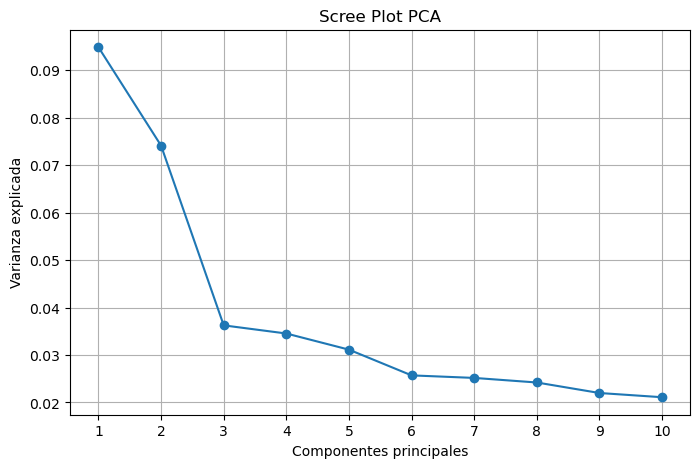

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(varianza_explicada)+1),
    varianza_explicada,
    marker='o'
)

plt.xlabel("Componentes principales")
plt.ylabel("Varianza explicada")
plt.title("Scree Plot PCA")

plt.xticks(range(1, len(varianza_explicada)+1))

plt.grid(True)

plt.show()

**Justificación dimensiones a usar:**

Al hacer el PCA y tratar de escoger las dimensiones con el criterio de Kaiser, los eigenvalues eran superiores a 1 hasta en la dimension 20, por lo que se decidio hacer un analisis por el metodo del codo. De acuerdo al scree plot se considera usar 3 componentes, ya que a partir de dicha dimension se empieza a estabilizar la varianza explicada.

In [9]:
from pyspark.ml.feature import PCA

pca_final = PCA(
    k=3,
    inputCol="features",
    outputCol="pca_features"
)

modelo_pca_final = pca_final.fit(df_ml)

df_pca = modelo_pca_final.transform(df_ml)

df_pca.select("pca_features").show(5, truncate=False)

+------------------------------------------------------------+
|pca_features                                                |
+------------------------------------------------------------+
|[-0.6193836901890398,1.8968139379168036,-3.969286319447935] |
|[-5.153755803653858,-1.5287246911498114,-1.3610653440562468]|
|[-1.1542645640457798,1.5863974090880666,-4.2462014355106295]|
|[4.27380603076853,-7.450578199863438,-10.133842849297627]   |
|[5.9940260831439,-12.719948289089269,-6.208696319390766]    |
+------------------------------------------------------------+
only showing top 5 rows


## 4. K-Means

In [10]:
from pyspark.ml.clustering import KMeans

costos = []

for k in range(2, 11):
    
    kmeans = KMeans(
        featuresCol="pca_features",
        k=k,
        seed=42
    )
    
    modelo_kmeans = kmeans.fit(df_pca)
    
    costos.append(modelo_kmeans.summary.trainingCost)

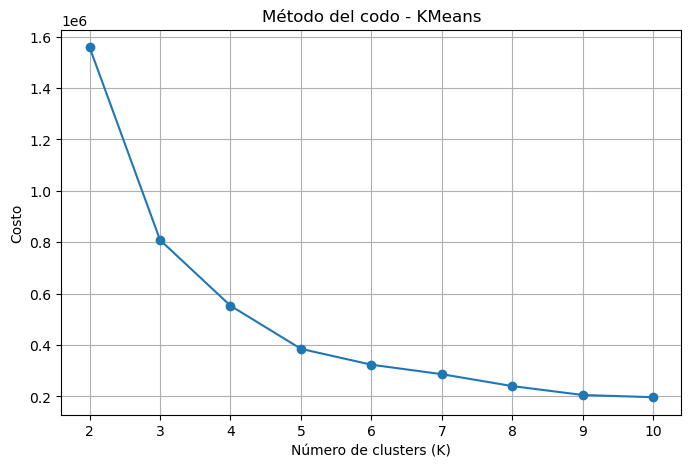

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(2,11), costos, marker='o')

plt.xlabel("Número de clusters (K)")
plt.ylabel("Costo")
plt.title("Método del codo - KMeans")

plt.grid(True)

plt.show()

El codo se observa al rededor de K=5 ya que a partir de ahi la curva empieza a aplanarse.

## 5. Analisis perfiles K-Means

In [12]:
from pyspark.ml.clustering import KMeans

kmeans_final = KMeans(
    featuresCol="pca_features",
    predictionCol="cluster",
    k=5,
    seed=42
)

modelo_final = kmeans_final.fit(df_pca)

df_clusters = modelo_final.transform(df_pca)

df_clusters.select("cluster").show(10)

+-------+
|cluster|
+-------+
|      4|
|      2|
|      4|
|      1|
|      1|
|      2|
|      4|
|      3|
|      0|
|      3|
+-------+
only showing top 10 rows


In [13]:
df_clusters.groupBy("cluster") \
    .count() \
    .orderBy("cluster") \
    .show()

+-------+-----+
|cluster|count|
+-------+-----+
|      0| 5816|
|      1| 3990|
|      2|25061|
|      3|50437|
|      4|53461|
+-------+-----+



### **Desempeño académico**

In [16]:
from pyspark.sql.functions import avg, count, round

perfil_academico_clusters = df_clusters.groupBy("cluster") \
    .agg(
        count("*").alias("N_ESTUDIANTES"),
        round(avg("PUNT_INGLES"), 2).alias("PROM_INGLES"),
        round(avg("PUNT_SOCIALES_CIUDADANAS"), 2).alias("PROM_SOCIALES"),
        round(avg("PUNT_C_NATURALES"), 2).alias("PROM_NATURALES")
    ) \
    .orderBy("PROM_INGLES", ascending=False)

perfil_academico_clusters.show(truncate=False)

+-------+-------------+-----------+-------------+--------------+
|cluster|N_ESTUDIANTES|PROM_INGLES|PROM_SOCIALES|PROM_NATURALES|
+-------+-------------+-----------+-------------+--------------+
|2      |25061        |60.24      |54.67        |55.9          |
|3      |50437        |51.07      |48.55        |50.47         |
|1      |3990         |46.54      |44.51        |45.69         |
|4      |53461        |43.6       |42.57        |44.97         |
|0      |5816         |43.4       |42.4         |42.04         |
+-------+-------------+-----------+-------------+--------------+



In [17]:
from pyspark.sql.functions import sum as spark_sum

total_cluster = df_clusters.groupBy("cluster") \
    .agg(count("*").alias("TOTAL_CLUSTER"))

perfil_contexto_clusters = df_clusters.groupBy(
    "cluster",
    "ACCESO_TECNOLOGICO"
).agg(
    count("*").alias("N")
).join(
    total_cluster,
    on="cluster"
).withColumn(
    "PORCENTAJE",
    round((col("N") / col("TOTAL_CLUSTER")) * 100, 2)
).orderBy("cluster", "ACCESO_TECNOLOGICO")

perfil_contexto_clusters.show(truncate=False)

+-------+------------------+-----+-------------+----------+
|cluster|ACCESO_TECNOLOGICO|N    |TOTAL_CLUSTER|PORCENTAJE|
+-------+------------------+-----+-------------+----------+
|0      |Alto acceso       |50   |5816         |0.86      |
|0      |Bajo acceso       |5766 |5816         |99.14     |
|1      |Alto acceso       |2    |3990         |0.05      |
|1      |Bajo acceso       |3988 |3990         |99.95     |
|2      |Alto acceso       |24325|25061        |97.06     |
|2      |Bajo acceso       |736  |25061        |2.94      |
|3      |Alto acceso       |43484|50437        |86.21     |
|3      |Bajo acceso       |6953 |50437        |13.79     |
|4      |Alto acceso       |573  |53461        |1.07      |
|4      |Bajo acceso       |52888|53461        |98.93     |
+-------+------------------+-----+-------------+----------+



In [18]:
perfil_estrato_clusters = df_clusters.groupBy(
    "cluster",
    "FAMI_ESTRATOVIVIENDA"
).agg(
    count("*").alias("N")
).join(
    total_cluster,
    on="cluster"
).withColumn(
    "PORCENTAJE",
    round((col("N") / col("TOTAL_CLUSTER")) * 100, 2)
).orderBy("cluster", "FAMI_ESTRATOVIVIENDA")

perfil_estrato_clusters.show(100, truncate=False)

+-------+--------------------+-----+-------------+----------+
|cluster|FAMI_ESTRATOVIVIENDA|N    |TOTAL_CLUSTER|PORCENTAJE|
+-------+--------------------+-----+-------------+----------+
|0      |Estrato 1           |154  |5816         |2.65      |
|0      |Estrato 2           |182  |5816         |3.13      |
|0      |Estrato 3           |104  |5816         |1.79      |
|0      |Estrato 4           |33   |5816         |0.57      |
|0      |Estrato 5           |15   |5816         |0.26      |
|0      |Estrato 6           |8    |5816         |0.14      |
|0      |SIN                 |5288 |5816         |90.92     |
|0      |Sin Estrato         |32   |5816         |0.55      |
|1      |Estrato 1           |508  |3990         |12.73     |
|1      |Estrato 2           |686  |3990         |17.19     |
|1      |Estrato 3           |437  |3990         |10.95     |
|1      |Estrato 4           |120  |3990         |3.01      |
|1      |Estrato 5           |33   |3990         |0.83      |
|1      

In [19]:
perfil_naturaleza = df_clusters.groupBy(
    "cluster",
    "COLE_NATURALEZA"
).agg(
    count("*").alias("N")
).join(
    total_cluster,
    on="cluster"
).withColumn(
    "PORCENTAJE",
    round((col("N") / col("TOTAL_CLUSTER")) * 100, 2)
).orderBy("cluster", "COLE_NATURALEZA")

perfil_naturaleza.show(truncate=False)

+-------+---------------+-----+-------------+----------+
|cluster|COLE_NATURALEZA|N    |TOTAL_CLUSTER|PORCENTAJE|
+-------+---------------+-----+-------------+----------+
|0      |NO OFICIAL     |1976 |5816         |33.98     |
|0      |OFICIAL        |3840 |5816         |66.02     |
|1      |NO OFICIAL     |1131 |3990         |28.35     |
|1      |OFICIAL        |2859 |3990         |71.65     |
|2      |NO OFICIAL     |22119|25061        |88.26     |
|2      |OFICIAL        |2942 |25061        |11.74     |
|3      |NO OFICIAL     |5645 |50437        |11.19     |
|3      |OFICIAL        |44792|50437        |88.81     |
|4      |NO OFICIAL     |6809 |53461        |12.74     |
|4      |OFICIAL        |46652|53461        |87.26     |
+-------+---------------+-----+-------------+----------+



In [20]:
perfil_jornada = df_clusters.groupBy(
    "cluster",
    "COLE_JORNADA"
).agg(
    count("*").alias("N")
).join(
    total_cluster,
    on="cluster"
).withColumn(
    "PORCENTAJE",
    round((col("N") / col("TOTAL_CLUSTER")) * 100, 2)
).orderBy("cluster", "COLE_JORNADA")

perfil_jornada.show(100, truncate=False)

+-------+------------+-----+-------------+----------+
|cluster|COLE_JORNADA|N    |TOTAL_CLUSTER|PORCENTAJE|
+-------+------------+-----+-------------+----------+
|0      |COMPLETA    |505  |5816         |8.68      |
|0      |MAÑANA      |2124 |5816         |36.52     |
|0      |NOCHE       |944  |5816         |16.23     |
|0      |SABATINA    |1176 |5816         |20.22     |
|0      |TARDE       |603  |5816         |10.37     |
|0      |UNICA       |464  |5816         |7.98      |
|1      |COMPLETA    |410  |3990         |10.28     |
|1      |MAÑANA      |1619 |3990         |40.58     |
|1      |NOCHE       |528  |3990         |13.23     |
|1      |SABATINA    |575  |3990         |14.41     |
|1      |TARDE       |418  |3990         |10.48     |
|1      |UNICA       |440  |3990         |11.03     |
|2      |COMPLETA    |14195|25061        |56.64     |
|2      |MAÑANA      |7324 |25061        |29.22     |
|2      |NOCHE       |564  |25061        |2.25      |
|2      |SABATINA    |1334 |

In [21]:
perfil_bilingue = df_clusters.groupBy(
    "cluster",
    "COLE_BILINGUE"
).agg(
    count("*").alias("N")
).join(
    total_cluster,
    on="cluster"
).withColumn(
    "PORCENTAJE",
    round((col("N") / col("TOTAL_CLUSTER")) * 100, 2)
).orderBy("cluster", "COLE_BILINGUE")

perfil_bilingue.show(truncate=False)

+-------+-------------+-----+-------------+----------+
|cluster|COLE_BILINGUE|N    |TOTAL_CLUSTER|PORCENTAJE|
+-------+-------------+-----+-------------+----------+
|0      |N            |4762 |5816         |81.88     |
|0      |S            |53   |5816         |0.91      |
|0      |SIN          |1001 |5816         |17.21     |
|1      |N            |3413 |3990         |85.54     |
|1      |S            |29   |3990         |0.73      |
|1      |SIN          |548  |3990         |13.73     |
|2      |N            |19099|25061        |76.21     |
|2      |S            |335  |25061        |1.34      |
|2      |SIN          |5627 |25061        |22.45     |
|3      |N            |45225|50437        |89.67     |
|3      |S            |277  |50437        |0.55      |
|3      |SIN          |4935 |50437        |9.78      |
|4      |N            |46049|53461        |86.14     |
|4      |S            |623  |53461        |1.17      |
|4      |SIN          |6789 |53461        |12.7      |
+-------+-

In [22]:
perfil_genero = df_clusters.groupBy(
    "cluster",
    "ESTU_GENERO"
).agg(
    count("*").alias("N")
).join(
    total_cluster,
    on="cluster"
).withColumn(
    "PORCENTAJE",
    round((col("N") / col("TOTAL_CLUSTER")) * 100, 2)
).orderBy("cluster", "ESTU_GENERO")

perfil_genero.show(truncate=False)

+-------+-----------+-----+-------------+----------+
|cluster|ESTU_GENERO|N    |TOTAL_CLUSTER|PORCENTAJE|
+-------+-----------+-----+-------------+----------+
|0      |F          |3223 |5816         |55.42     |
|0      |M          |2593 |5816         |44.58     |
|1      |F          |1923 |3990         |48.2      |
|1      |M          |2067 |3990         |51.8      |
|2      |F          |11925|25061        |47.58     |
|2      |M          |13136|25061        |52.42     |
|3      |F          |27097|50437        |53.72     |
|3      |M          |23340|50437        |46.28     |
|4      |F          |31571|53461        |59.05     |
|4      |M          |21890|53461        |40.95     |
+-------+-----------+-----+-------------+----------+



In [23]:
perfil_automovil = df_clusters.groupBy(
    "cluster",
    "FAMI_TIENEAUTOMOVIL"
).agg(
    count("*").alias("N")
).join(
    total_cluster,
    on="cluster"
).withColumn(
    "PORCENTAJE",
    round((col("N") / col("TOTAL_CLUSTER")) * 100, 2)
).orderBy("cluster", "FAMI_TIENEAUTOMOVIL")

perfil_automovil.show(truncate=False)

+-------+-------------------+-----+-------------+----------+
|cluster|FAMI_TIENEAUTOMOVIL|N    |TOTAL_CLUSTER|PORCENTAJE|
+-------+-------------------+-----+-------------+----------+
|0      |No                 |4579 |5816         |78.73     |
|0      |SIN                |171  |5816         |2.94      |
|0      |Si                 |1066 |5816         |18.33     |
|1      |No                 |2    |3990         |0.05      |
|1      |SIN                |3985 |3990         |99.87     |
|1      |Si                 |3    |3990         |0.08      |
|2      |No                 |8334 |25061        |33.25     |
|2      |SIN                |25   |25061        |0.1       |
|2      |Si                 |16702|25061        |66.65     |
|3      |No                 |37908|50437        |75.16     |
|3      |SIN                |203  |50437        |0.4       |
|3      |Si                 |12326|50437        |24.44     |
|4      |No                 |49623|53461        |92.82     |
|4      |SIN            

In [24]:
perfil_lavadora = df_clusters.groupBy(
    "cluster",
    "FAMI_TIENELAVADORA"
).agg(
    count("*").alias("N")
).join(
    total_cluster,
    on="cluster"
).withColumn(
    "PORCENTAJE",
    round((col("N") / col("TOTAL_CLUSTER")) * 100, 2)
).orderBy("cluster", "FAMI_TIENELAVADORA")

perfil_lavadora.show(truncate=False)

+-------+------------------+-----+-------------+----------+
|cluster|FAMI_TIENELAVADORA|N    |TOTAL_CLUSTER|PORCENTAJE|
+-------+------------------+-----+-------------+----------+
|0      |No                |1593 |5816         |27.39     |
|0      |SIN               |90   |5816         |1.55      |
|0      |Si                |4133 |5816         |71.06     |
|1      |No                |4    |3990         |0.1       |
|1      |SIN               |3975 |3990         |99.62     |
|1      |Si                |11   |3990         |0.28      |
|2      |No                |577  |25061        |2.3       |
|2      |SIN               |7    |25061        |0.03      |
|2      |Si                |24477|25061        |97.67     |
|3      |No                |5000 |50437        |9.91      |
|3      |SIN               |81   |50437        |0.16      |
|3      |Si                |45356|50437        |89.93     |
|4      |No                |20015|53461        |37.44     |
|4      |SIN               |104  |53461 

### **Análisis clústers**

* **Cluster 0:** Es el segundo grupo mas pequeño y con bajo desempeño academico en promedio para todas las areas, y acceso tecnologico limitado (99.14% bajo acceso), pertenece a colegios oficiales en su mayoria con 66.02% y tienen ausencia de automovil en 78.73%, con mas jornadas de mañana o sabatina.

* **Cluster 1:** Es el cluster mas pequeño y tiene alta presencia de la categoria "SIN" (Sin informacion) en las variables de hogar y estrato, es el que tiene casi totalmente acceso tecnologico bajo con 99.95%, predominan colegios oficiales con 71.65% y jornada en la mañana con 40.58%. Academicamente tiene un desempeño medio-bajo, pero superior a los estudiantes del cluster 0.

* **Cluster 2:** Es el grupo con mejor rendimiento academico y tecnologico, cuenta con 97.06% tecnologico y 66.65% poseen automovil, es predominante los colegios no oficiales con 88.26%, la jornada completa con 56.64% y tiene los estratos 2,3,4 (los cuales en el EDA vimos que tenian los mejores resultados en todas las areas).

* **Cluster 3:** Es un grupo grande con buen desempeli academico y acceso tecnologico con 86.21%, aunque tiene menor nivel socieconomico que el cluster 2 porque no tiene una alta tendencia a tener automovil (esta en 24.44%), aqui tambien predominan los colegios no oficiales con 88.81% y jornada en la mañana con 53.95%. (Es el segundo mejor rendimiento academico promedio)

* **Cluster 4:** Es el cluster con mas estudiantes y tiene un bajo acceso tecnologico con 98.93%, tiene muy baja tendencia a automovil con 6.75% y se inclina a colegios oficiales con87.26%. Su desempeño academico es bajo, similar al cluster 0, con la unica diferencia de que a estos estudiantes les fue mejor en ciencias naturales.

## 6. Modelo supervisado

### 6.1 Regresión Logistica

In [25]:
df_modelo = df_ml.select("DESEMPENO", "features").cache()

train, test = df_modelo.randomSplit([0.8, 0.2], seed=42)

print("Train:", train.count())
print("Test:", test.count())

Train: 111236
Test: 27529


In [26]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="DESEMPENO",
    maxIter=20
)

modelo_lr = lr.fit(train)

pred_lr = modelo_lr.transform(test)

pred_lr.select("DESEMPENO", "prediction", "probability").show(5, truncate=False)

+---------+----------+------------------------------------------+
|DESEMPENO|prediction|probability                               |
+---------+----------+------------------------------------------+
|0        |0.0       |[0.9999998156537377,1.8434626225527495E-7]|
|0        |0.0       |[0.9999997480646885,2.519353115015832E-7] |
|0        |0.0       |[0.9997517135734161,2.482864265839213E-4] |
|0        |0.0       |[0.9985253490071737,0.0014746509928262874]|
|0        |0.0       |[0.9924896554058336,0.00751034459416644]  |
+---------+----------+------------------------------------------+
only showing top 5 rows


In [27]:
pred_lr_pd = pred_lr.select("DESEMPENO", "prediction", "probability").toPandas()

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

y_true = pred_lr_pd["DESEMPENO"]
y_pred = pred_lr_pd["prediction"]
y_prob = pred_lr_pd["probability"].apply(lambda x: float(x[1]))

print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")
print(f"F1: {f1_score(y_true, y_pred):.4f}")
print(f"AUC: {roc_auc_score(y_true, y_prob):.4f}")

confusion_matrix(y_true, y_pred)

Accuracy: 0.9742
Precision: 0.8770
Recall: 0.8607
F1: 0.8688
AUC: 0.9941


array([[24464,   330],
       [  381,  2354]], dtype=int64)

El desempeño es alto, lo que indica una buena capacidad de diferenciar los estudiantes con alto y bajo desempeño. El recall de 86.07% muestra que el modelo logra identidicar la mayoria de los estudiantes con alto desempeño.

En cuanto a la matriz de confusion, se puede ver que clasifico correctamente la mayor parte de los casos, con 24.464 estudiantes con bajo desempeño y 2.354 con alto desempeño de manera correcta. Los errores fueron relativamente bajos, con 330 falsos positivos y 381 falsos negativos, mostrando un equilibrio entre la clase positiva y negativa.

**Validación cruzada**

In [30]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.classification import LogisticRegression

lr_cv = LogisticRegression(
    featuresCol="features",
    labelCol="DESEMPENO"
)

paramGrid = ParamGridBuilder() \
    .addGrid(lr_cv.regParam, [0.01, 0.1]) \
    .addGrid(lr_cv.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

evaluator = BinaryClassificationEvaluator(
    labelCol="DESEMPENO",
    metricName="areaUnderROC"
)

crossval = CrossValidator(
    estimator=lr_cv,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)

modelo_cv = crossval.fit(train)

In [31]:
mejor_modelo = modelo_cv.bestModel

print("Mejor regParam:", mejor_modelo._java_obj.getRegParam())
print("Mejor elasticNetParam:", mejor_modelo._java_obj.getElasticNetParam())

Mejor regParam: 0.01
Mejor elasticNetParam: 1.0


In [32]:
pred_cv = mejor_modelo.transform(test)

pred_cv_pd = pred_cv.select(
    "DESEMPENO",
    "prediction",
    "probability"
).toPandas()

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

y_true = pred_cv_pd["DESEMPENO"]
y_pred = pred_cv_pd["prediction"]
y_prob = pred_cv_pd["probability"].apply(lambda x: float(x[1]))

print("=== MEJORES HIPERPARÁMETROS ===")
print("regParam:", mejor_modelo._java_obj.getRegParam())
print("elasticNetParam:", mejor_modelo._java_obj.getElasticNetParam())

print("\n=== MÉTRICAS MODELO FINAL ===")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")
print(f"F1: {f1_score(y_true, y_pred):.4f}")
print(f"AUC: {roc_auc_score(y_true, y_prob):.4f}")

print("\n=== MATRIZ DE CONFUSIÓN ===")
print(confusion_matrix(y_true, y_pred))

=== MEJORES HIPERPARÁMETROS ===
regParam: 0.01
elasticNetParam: 1.0

=== MÉTRICAS MODELO FINAL ===
Accuracy: 0.9726
Precision: 0.9267
Recall: 0.7861
F1: 0.8506
AUC: 0.9941

=== MATRIZ DE CONFUSIÓN ===
[[24624   170]
 [  585  2150]]


Los mejores hiperparametros reflejan que el modelo funciono mejor con una regularizacion baja y un enfoque tipo Lasso, ayudando a reducir complejidad y mantener solo las relaciones mas relevantes entre las variables y el desempeño estudiantil.

El desempeño se mantuvo alto luego de la validacion cruzada, lo que mostro una mejor capacidad de diferenciar los estudiantes de alto y bajo desempeloi, pero el recall bajo a 78.61%, y el modelo predice mejor los estudiantes con desempeño alto.

En la matriz de confusion se puede ver que la matriz inicial el modelo tenia 381 falsos negativos y 330 falsos positivos, entonces despues de la validacion cruzada los falsos positivos disminuyeron a 170, pero los falsos negativos aumentaron a 585. El modelo se volvio mas conservador al clasificar estudiantes con alto desempeño, reduciendo errores al asignar estudiantes de bajo desempeño como altos, pero deja escapar mas estudiantes que realmente tuvieron buen desempeño.



### 6.2 Random Forest

In [28]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="DESEMPENO",
    numTrees=30,
    maxDepth=6,
    seed=42
)

modelo_rf = rf.fit(train)

pred_rf = modelo_rf.transform(test)

pred_rf.select("DESEMPENO", "prediction", "probability").show(5, truncate=False)

+---------+----------+-----------------------------------------+
|DESEMPENO|prediction|probability                              |
+---------+----------+-----------------------------------------+
|0        |0.0       |[0.9557781419168576,0.04422185808314236] |
|0        |0.0       |[0.9557781419168576,0.04422185808314236] |
|0        |0.0       |[0.9557781419168576,0.04422185808314236] |
|0        |0.0       |[0.9705752751928031,0.029424724807197006]|
|0        |0.0       |[0.9642807045851517,0.035719295414848355]|
+---------+----------+-----------------------------------------+
only showing top 5 rows


In [29]:
pred_rf_pd = pred_rf.select("DESEMPENO", "prediction", "probability").toPandas()

y_true = pred_rf_pd["DESEMPENO"]
y_pred = pred_rf_pd["prediction"]
y_prob = pred_rf_pd["probability"].apply(lambda x: float(x[1]))

print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")
print(f"F1: {f1_score(y_true, y_pred):.4f}")
print(f"AUC: {roc_auc_score(y_true, y_prob):.4f}")

confusion_matrix(y_true, y_pred)

Accuracy: 0.9524
Precision: 0.9618
Recall: 0.5426
F1: 0.6938
AUC: 0.9861


array([[24735,    59],
       [ 1251,  1484]], dtype=int64)

El random forest tiene buen desempeño, pero el recall es mucho mas bajo 54.26%, por lo que el modelo tuvo mas dificultad para identificar correctamente a los estudiantes con desempeño alto.

En la matriz de confusion se ve que que el modelo clasifico correctamente 24.735 estudiantes con bajo desempeño y 1.484 con alto desempeño. Aunque los falsos positivos fueron muy bajos (59), los falsos negativos aumentaron a 1.251, indicando que el modelo fue mucho mas conservador y dejo escapar una cantidad importante de estudiantes que realmente pertenecian al grupo de alto desempeño.

**Validación cruzada**

In [36]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.classification import RandomForestClassifier

rf_cv = RandomForestClassifier(
    featuresCol="features",
    labelCol="DESEMPENO",
    seed=42
)

paramGrid_rf = ParamGridBuilder() \
    .addGrid(rf_cv.numTrees, [20, 30]) \
    .addGrid(rf_cv.maxDepth, [5, 8]) \
    .build()

evaluator_rf = BinaryClassificationEvaluator(
    labelCol="DESEMPENO",
    metricName="areaUnderROC"
)

crossval_rf = CrossValidator(
    estimator=rf_cv,
    estimatorParamMaps=paramGrid_rf,
    evaluator=evaluator_rf,
    numFolds=2,
    seed=42
)

modelo_cv_rf = crossval_rf.fit(train)

mejor_rf = modelo_cv_rf.bestModel

In [37]:
pred_cv_rf = mejor_rf.transform(test)

pred_cv_rf_pd = pred_cv_rf.select(
    "DESEMPENO",
    "prediction",
    "probability"
).toPandas()

y_true = pred_cv_rf_pd["DESEMPENO"]
y_pred = pred_cv_rf_pd["prediction"]
y_prob = pred_cv_rf_pd["probability"].apply(lambda x: float(x[1]))

print("=== MEJORES HIPERPARÁMETROS RF ===")
print("numTrees:", mejor_rf.getNumTrees)
print("maxDepth:", mejor_rf.getOrDefault("maxDepth"))

print("\n=== MÉTRICAS RF FINAL ===")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")
print(f"F1: {f1_score(y_true, y_pred):.4f}")
print(f"AUC: {roc_auc_score(y_true, y_prob):.4f}")

print("\n=== MATRIZ DE CONFUSIÓN ===")
print(confusion_matrix(y_true, y_pred))

=== MEJORES HIPERPARÁMETROS RF ===
numTrees: 30
maxDepth: 8

=== MÉTRICAS RF FINAL ===
Accuracy: 0.9659
Precision: 0.9343
Recall: 0.7068
F1: 0.8047
AUC: 0.9896

=== MATRIZ DE CONFUSIÓN ===
[[24658   136]
 [  802  1933]]


Los hiperparametros que selecciono indican que el modelo tuvo mejores resultados usando una cantidad mas moderada de arboles y una profundidad mayor.

Con la validación cruzada el recal aumento de 54.26% a 70.68% y el F1 paso de 69.38% a 80.47%, mostrando una mejora importante en la identificacion de estudiantes con alto desempeño. El accuarcy y el AUC subieron un poco tambien.

En la matriz de confusión se pudo ver que a comparación del primer random forest los falsos negativos disminuyeron a 802, lo que indica que el modelo mejoro la clasificacion de estudiantes con alto desempeño, pero os falsos positivos aumentaron de 59 a 136, entonces el modelo logro equilibrar mucho mejor entre precision y capacidad de deteccion.

In [42]:
import pandas as pd

importancias_pca = mejor_rf.featureImportances.toArray()

df_pca_importancia = pd.DataFrame({
    "Componente_PCA": [f"PCA_{i+1}" for i in range(len(importancias_pca))],
    "Importancia": importancias_pca
}).sort_values(
    by="Importancia",
    ascending=False
)

df_pca_importancia.head(3)

,Componente_PCA,Importancia
2,PCA_3,0.380297
1,PCA_2,0.322083
0,PCA_1,0.169375


De las tres dimensiones usadas, la que dio mejor siginificancia fue la tercera dimension con 38% de importancia, seguida de la segunda con 32.2%.


# COMPARACIÓN MODELOS (POST CROSS VALIDATION)

| Modelo              | Accuracy | Precision | Recall | F1     | AUC    |
| ------------------- | -------- | --------- | ------ | ------ | ------ |
| Regresión Logística | 0.9726   | 0.9267    | 0.7861 | 0.8506 | 0.9941 |
| Random Forest       | 0.9659   | 0.9343    | 0.7068 | 0.8047 | 0.9896 |


El mejor modelo fue la regresion logistica, aunque ambos modelos dieron resultados altos, pero la regresion mostro mas equilibrio general entre las metricas, con un recall y f1 score superiores, lo que indicaba una mejor capacidad para identificar correctamente estudiantes con alto desempeño sin perder demasiada precision. Ademas obtuvo el mayor AUC, mostrando una capacidad de discriminacion ligeramente superior frente al random forest.

